In [1]:
import pandas as pd
from scipy.stats import poisson

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import Bbox

import boto3

# Read Week History

In [28]:
df0 = pd.read_csv('history-2025-w27.csv', parse_dates=['Datetime'])
# df0

In [29]:
week_series = df0.set_index('Datetime')['CPM']
week_series

Datetime
2025-07-06 07:25:44    22
2025-07-06 07:26:44    10
2025-07-06 07:27:44    11
2025-07-06 07:28:44     9
2025-07-06 07:29:44     6
                       ..
2025-07-13 07:07:44    12
2025-07-13 07:08:44    12
2025-07-13 07:09:44    13
2025-07-13 07:10:44    10
2025-07-13 07:11:44     9
Name: CPM, Length: 10067, dtype: int64

In [30]:
week_name = week_series.index[0].strftime('%Y-w%U')
week_name 

'2025-w27'

In [31]:
week_title = week_series.index[0].strftime('Week %U of %Y · Honolulu')
week_title

'Week 27 of 2025 · Honolulu'

In [32]:
file_name_a = f'plot-a-{week_name}.png'
file_name_a

'plot-a-2025-w27.png'

In [33]:
file_name_b = f'plot-b-{week_name}.png'
file_name_b

'plot-b-2025-w27.png'

# Plot Week History

Text(0, 0.5, 'Counts Per Minute')

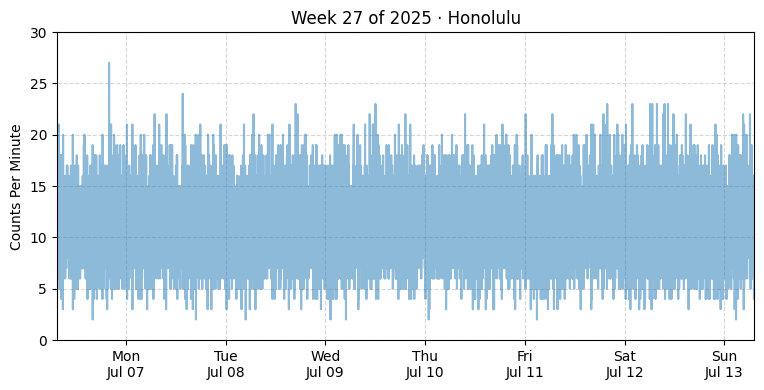

In [34]:
fig_a, ax = plt.subplots(1, 1, figsize=(9, 4))

ax.plot(week_series, color='#1f77b4', alpha=0.5)

ax.set_xlim(week_series.index[0], week_series.index[-1])
ax.set_ylim(0, 30)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%b %d'))
ax.grid(True, linestyle='--', alpha=0.5)

ax.set_title(week_title)
ax.set_ylabel('Counts Per Minute')

# Plot Week Histogram

In [35]:
week_histogram = week_series.value_counts(normalize=True).sort_index().rename('PMF')
# week_histogram

In [36]:
x = pd.Index(range(30 + 1), name='CPM')
y = poisson.pmf(x, week_series.mean())
week_poisson = pd.Series(y, index=x, name='PMF')
# week_poisson

In [37]:
stats = (
    f'x̄ = {week_series.mean():.3f}\n'
    f'σ² = {week_series.var():.3f}\n'
    f'min = {week_series.min():d}\n'
    f'max = {week_series.max():d}')

Text(0, 0.5, 'Probability')

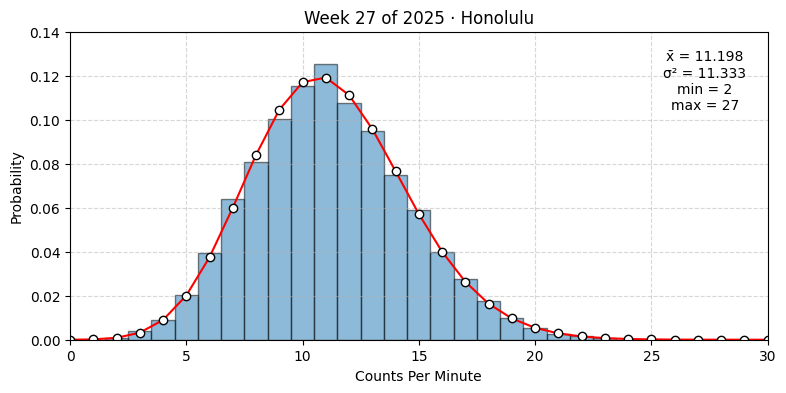

In [38]:
fig_b, ax = plt.subplots(1, 1, figsize=(9, 4))

ax.bar(week_histogram.index, week_histogram.values,
    width=1.0, align='center', color='#1f77b4', alpha=0.5, edgecolor='black')
ax.plot(week_poisson,
    color='red', marker='o', markerfacecolor='white', markeredgecolor='black')
ax.text(0.91, 0.84, stats,
    transform=ax.transAxes, va='center', ha='center')

ax.set_xlim(0, 30)
ax.set_ylim(0, 0.14)
ax.grid(True, linestyle='--', alpha=0.5)

ax.set_title(week_title)
ax.set_xlabel('Counts Per Minute')
ax.set_ylabel('Probability')

# Export And Upload Week Plots

In [39]:
bbox = Bbox.from_bounds(0.4, -0.1, 8.2, 4.0)
fig_a.savefig(file_name_a, dpi=300, bbox_inches=bbox)
fig_b.savefig(file_name_b, dpi=300, bbox_inches=bbox)

In [40]:
bucket = boto3.resource('s3').Bucket('hnlrad')
bucket.upload_file(file_name_a, file_name_a)
bucket.upload_file(file_name_b, file_name_b)